Processing DQN_1...


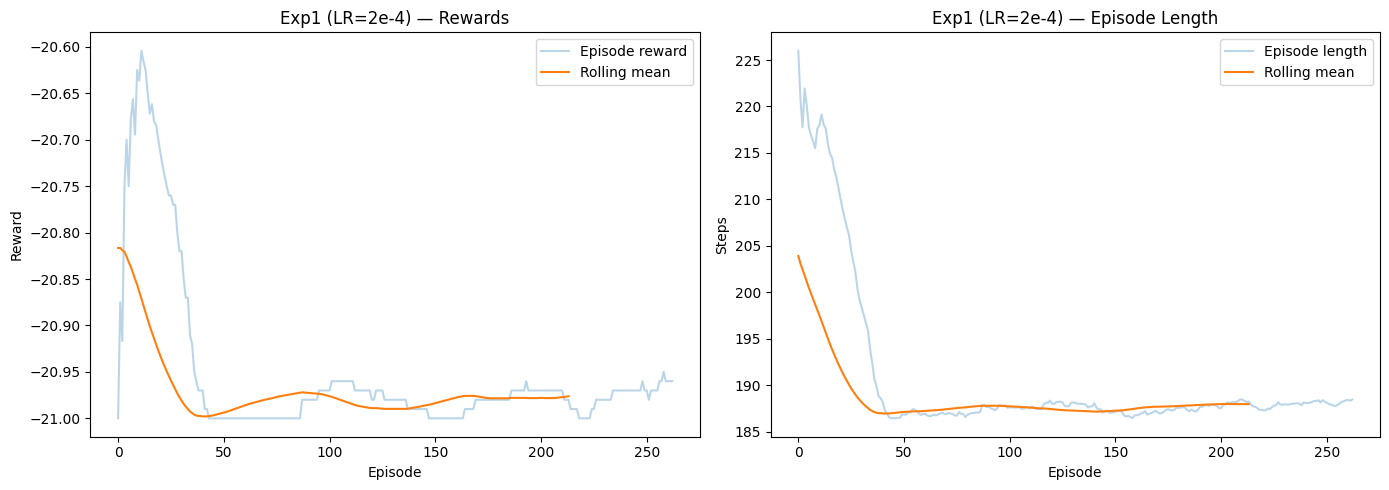

Processing DQN_10...


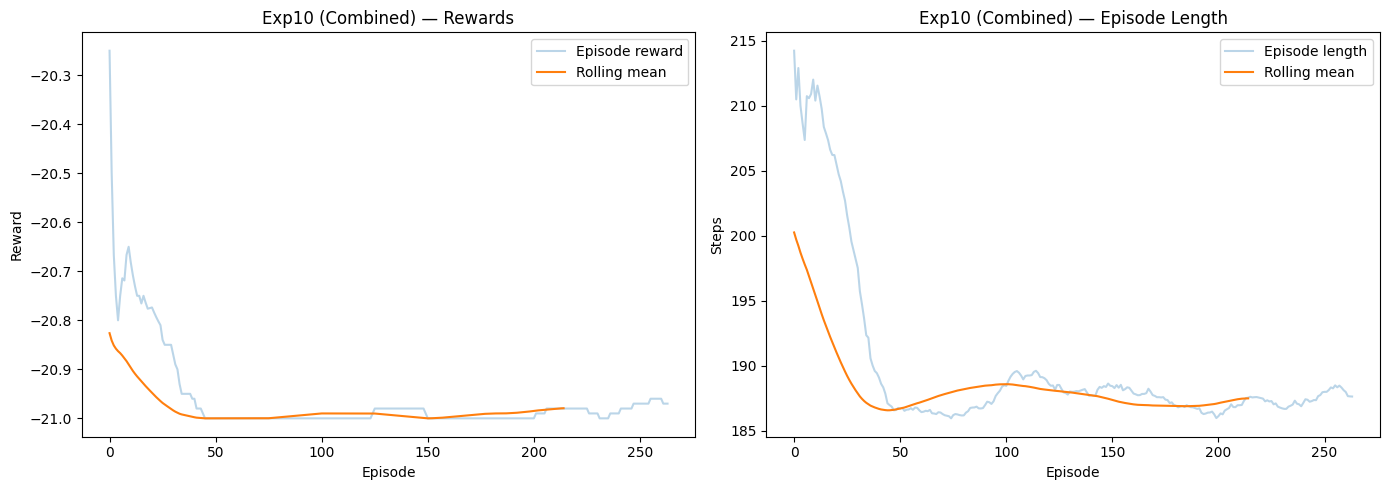

Processing DQN_11...


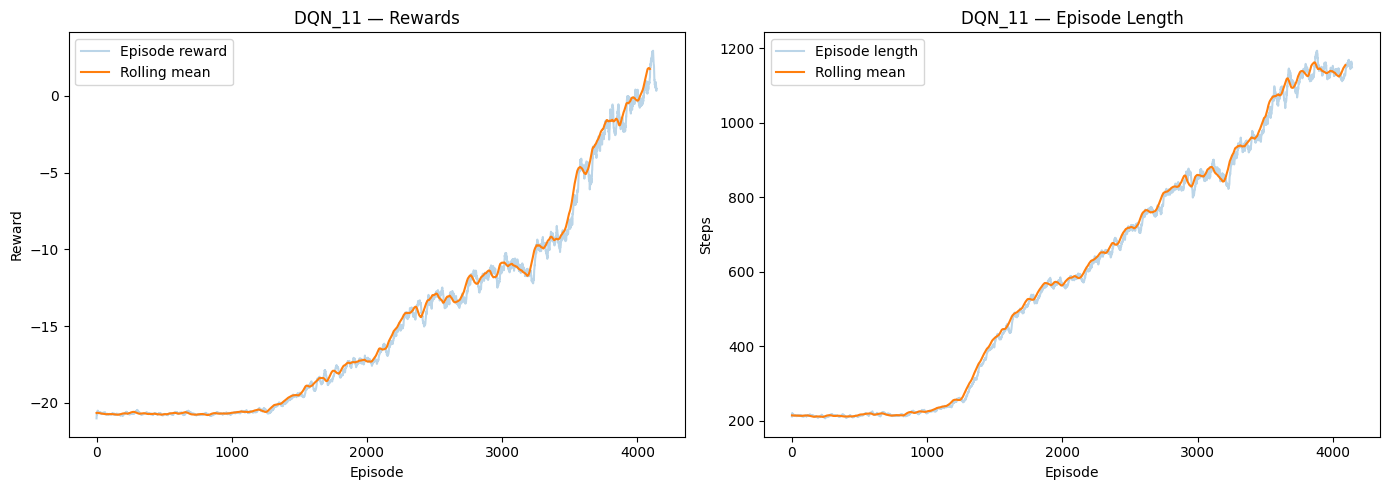

Processing DQN_2...


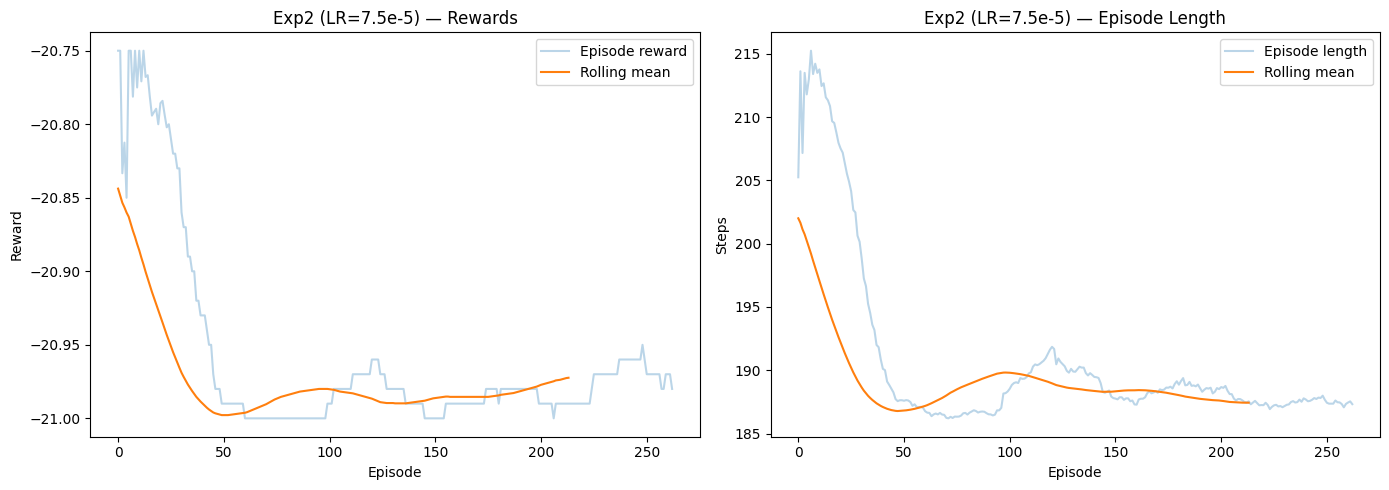

Processing DQN_3...


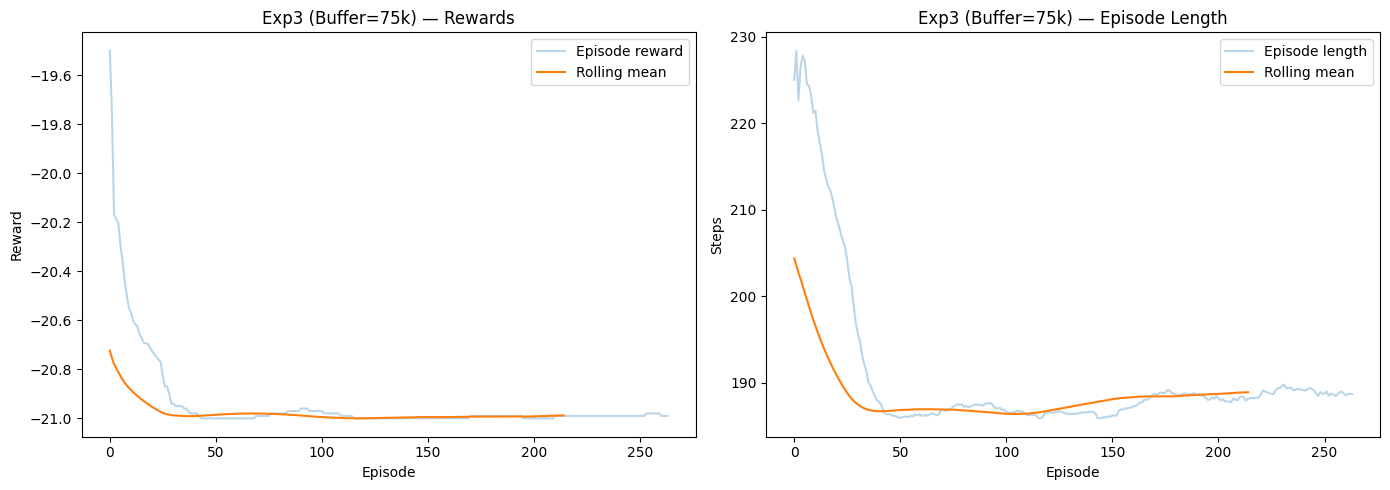

Processing DQN_4...


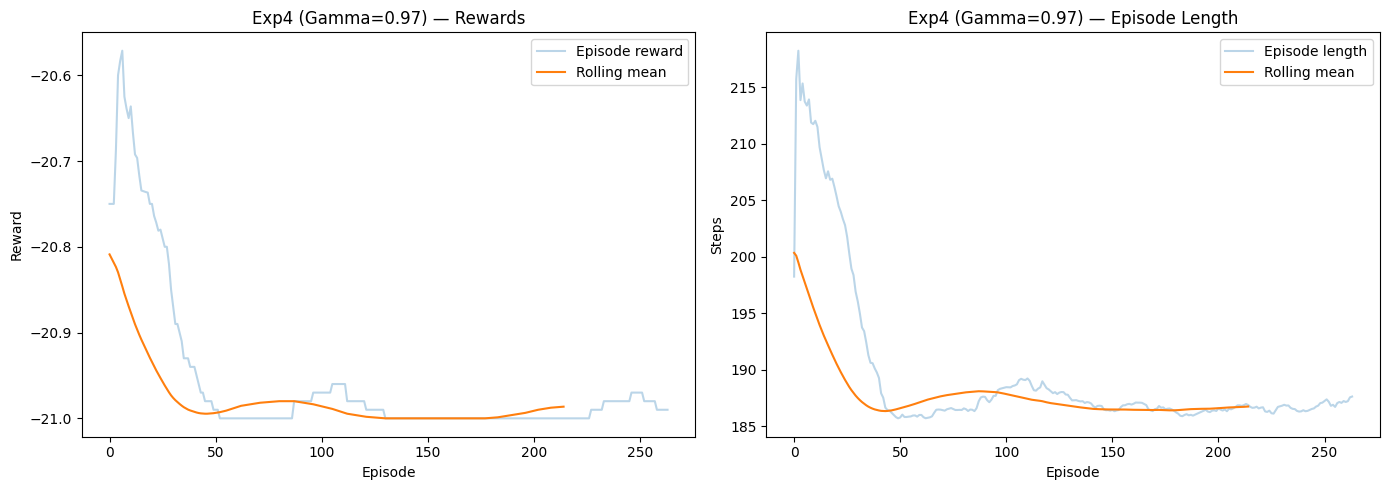

Processing DQN_5...


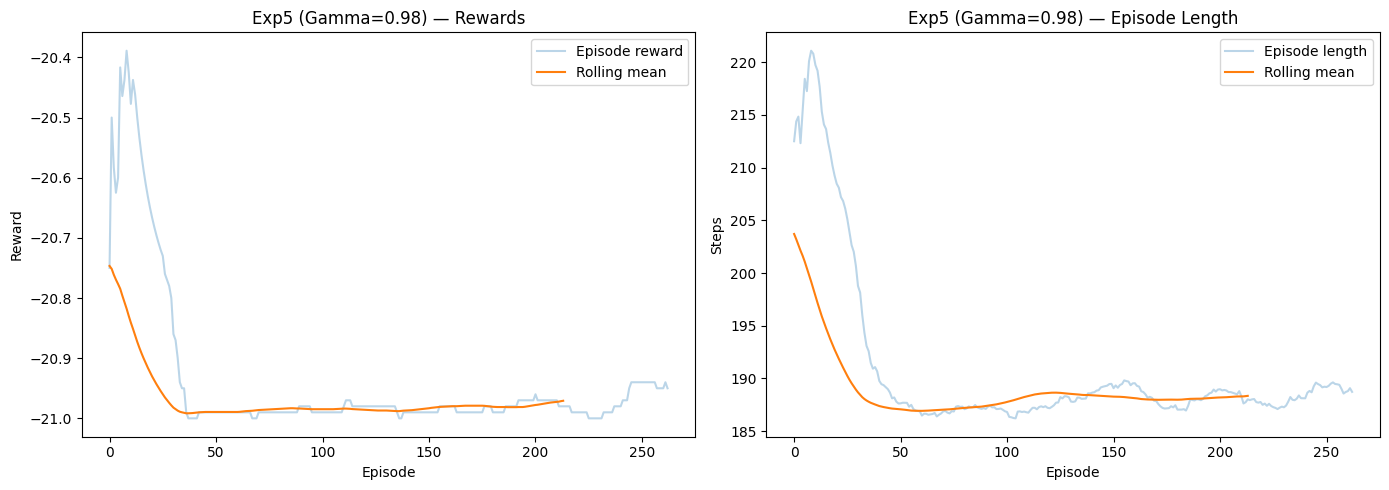

Processing DQN_6...


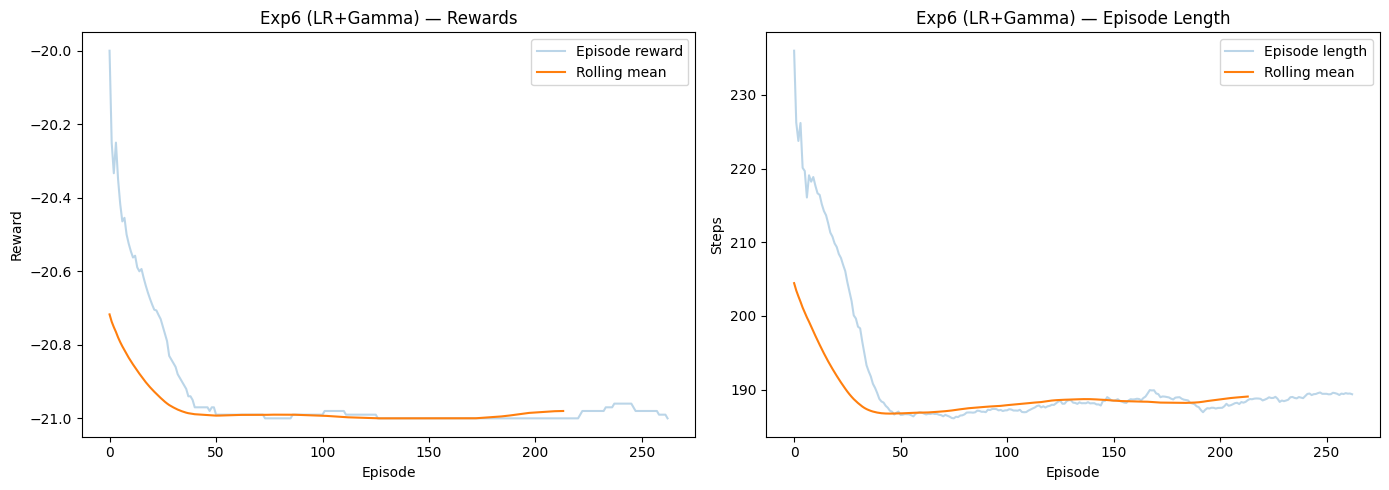

Processing DQN_7...


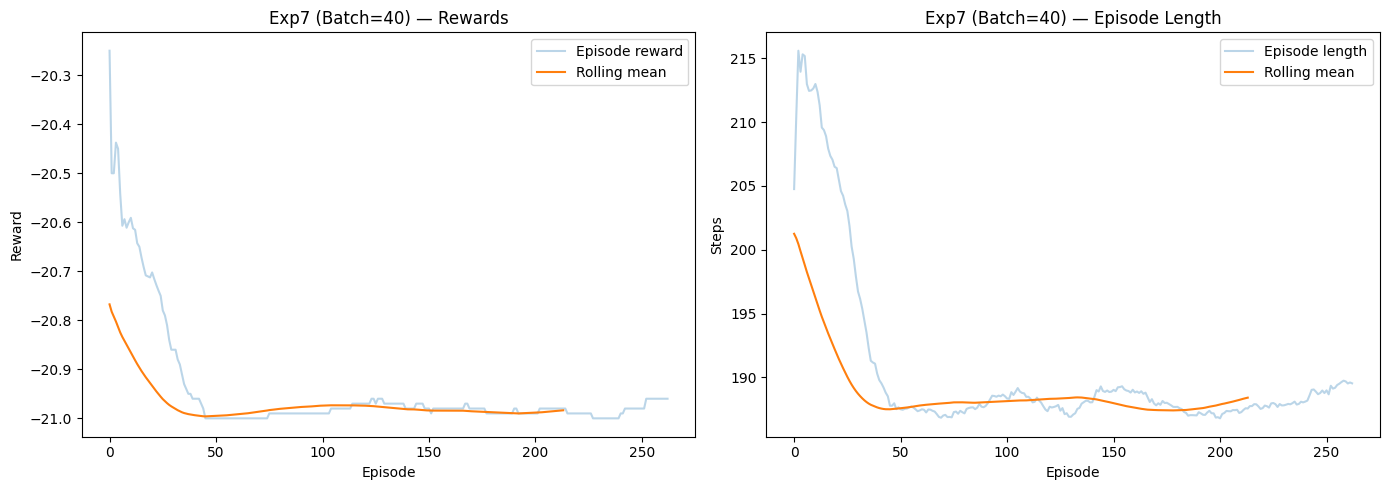

Processing DQN_8...


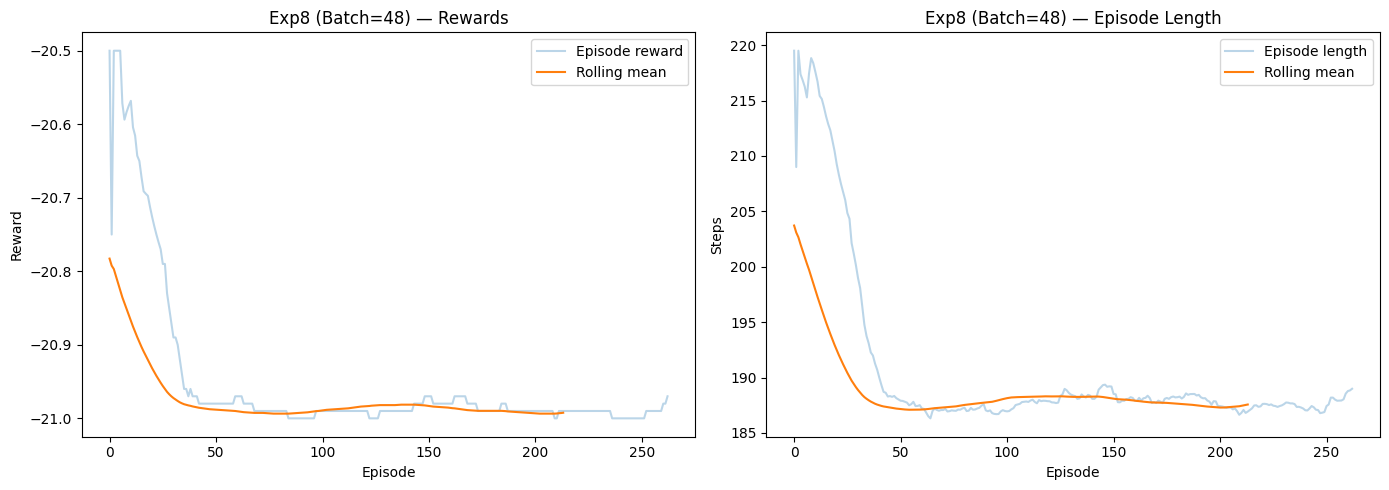

Processing DQN_9...


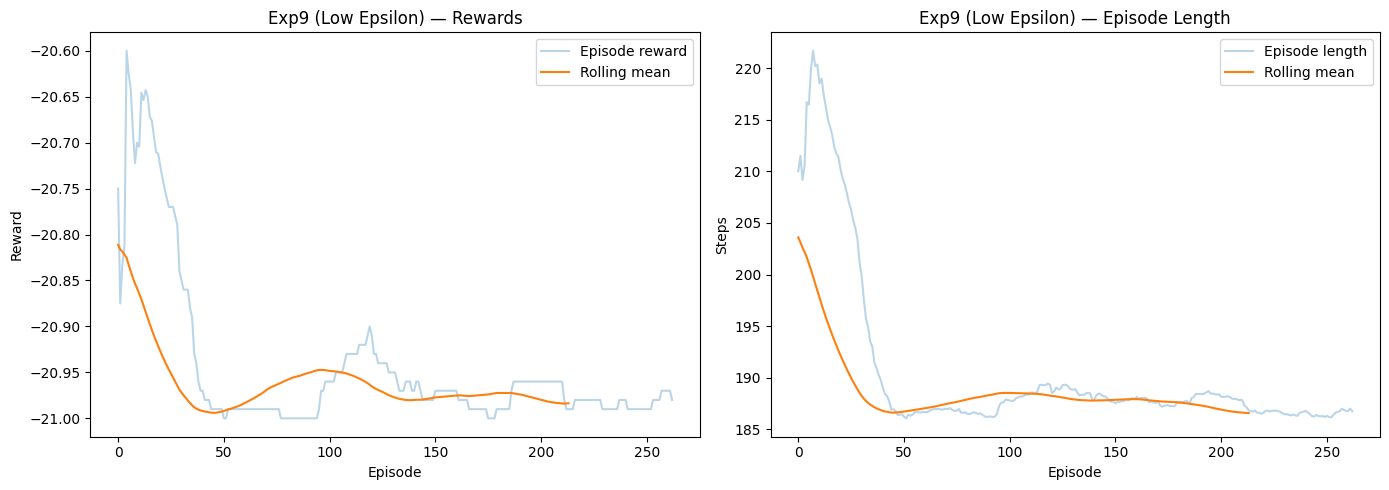

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

# SETTINGS
BASE_LOG_DIR = r"C:\Users\Administrator\Formative_3-Deep-Q-Learning\Dennis\tensorboard_logs"

# nicer experiment names
EXPERIMENT_NAMES = {
    "DQN_1": "Exp1 (LR=2e-4)",
    "DQN_2": "Exp2 (LR=7.5e-5)",
    "DQN_3": "Exp3 (Buffer=75k)",
    "DQN_4": "Exp4 (Gamma=0.97)",
    "DQN_5": "Exp5 (Gamma=0.98)",
    "DQN_6": "Exp6 (LR+Gamma)",
    "DQN_7": "Exp7 (Batch=40)",
    "DQN_8": "Exp8 (Batch=48)",
    "DQN_9": "Exp9 (Low Epsilon)",
    "DQN_10": "Exp10 (Combined)",
}

# HELPER: MOVING AVERAGE
def moving_average(data, window=50):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

# LOOP THROUGH EXPERIMENTS

for folder in sorted(os.listdir(BASE_LOG_DIR)):
    path = os.path.join(BASE_LOG_DIR, folder)

    if not os.path.isdir(path):
        continue

    print(f"Processing {folder}...")

    try:
        ea = event_accumulator.EventAccumulator(path)
        ea.Reload()

        # Extract metrics
        rewards = ea.Scalars("rollout/ep_rew_mean")
        lengths = ea.Scalars("rollout/ep_len_mean")

        reward_values = [x.value for x in rewards]
        length_values = [x.value for x in lengths]

        if len(reward_values) == 0:
            print(f"Skipping {folder} (no data)")
            continue

        # Smooth
        reward_smooth = moving_average(reward_values, 50)
        length_smooth = moving_average(length_values, 50)

        # Label
        title = EXPERIMENT_NAMES.get(folder, folder)

        # PLOT
       
        plt.figure(figsize=(14, 5))

        # Reward subplot
        plt.subplot(1, 2, 1)
        plt.plot(reward_values, alpha=0.3, label="Episode reward")
        plt.plot(reward_smooth, label="Rolling mean")
        plt.title(f"{title} — Rewards")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.legend()

        # Episode length subplot
        plt.subplot(1, 2, 2)
        plt.plot(length_values, alpha=0.3, label="Episode length")
        plt.plot(length_smooth, label="Rolling mean")
        plt.title(f"{title} — Episode Length")
        plt.xlabel("Episode")
        plt.ylabel("Steps")
        plt.legend()

        plt.tight_layout()

        # Save figure
        save_path = os.path.join(BASE_LOG_DIR, f"{folder}_plot.png")
        plt.savefig(save_path, dpi=300)

        plt.show()

    except Exception as e:
        print(f"Error processing {folder}: {e}")